In [65]:
import sys
sys.path.append("../scripts")

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import binned_statistic, binned_statistic_2d
import multiprocessing as mp

In [67]:
import niceplots
niceplots.initPlot()

import seaborn as sns
Cs = sns.color_palette("colorblind")
Cs

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

# Obtain k modes

In [68]:
from specs import *
from meer21cm import PowerSpectrum

ps = PowerSpectrum(
    wproj=wcs,
    num_pix_x=num_pix_x,
    num_pix_y=num_pix_y,
    nu=nu_arr,
    ra_range=ra_range,
    dec_range=dec_range,
    # downscale the resolution along line-of-sight
    downres_factor_radial = 6,
    # downscale the resolution on the transverse plane
    downres_factor_transverse = 3,
    omega_hi = 5e-4,
    tracer_bias_1 = 1.5,
    tracer_bias_2 = 1.5,
    mean_amp_1 = 'average_hi_temp',
    sigma_v_1=5,
    sigma_v_2=5,
)

ps.get_enclosing_box()

In [69]:
kmode3d = ps.k_mode
kx, ky, kz = ps.k_vec

kmask_simple = ~np.logical_or(
    kx[:, None, None]==0, np.logical_or(
        ky[:, None]==0, kz==0
    )
)
print(f"fraction of maked pixels {(~kmask_simple).astype(np.float64).mean()}")

fraction of maked pixels 0.1270338856545753


In [70]:
Nk = 25
kbins = np.geomspace(
    np.min(kmode3d[kmask_simple]),
    np.max(kmode3d[kmask_simple]),
    Nk,
)

In [71]:
kparr = ps.k_mode * ps.mu_mode
kperp = ps.k_mode * np.sqrt(np.clip(1 - ps.mu_mode**2, 0, 1))

kparrbins = np.geomspace(
    kparr[kmask_simple].min(),
    kparr[kmask_simple].max(),
    12
)

kperpbins = np.geomspace(
    kperp[kmask_simple].min(),
    kperp[kmask_simple].max(),
    12
)

In [72]:
kbc = np.sqrt(kbins[1:] * kbins[:-1])
kperpc = np.sqrt(kperpbins[1:] * kperpbins[:-1])
kparrc = np.sqrt(kparrbins[1:] * kparrbins[:-1])

# get 1D and cy power spectrum

In [73]:
def get_1d_power_sims(array):
    k = kmode3d[kmask_simple]
    power = array[kmask_simple]

    power_1d, _, _ = binned_statistic(
        k, power, statistic="mean", bins=kbins
    )
    return power_1d

def get_cy_power_sims(array):
    kpar = kparr[kmask_simple]
    kper = kperp[kmask_simple]
    power = array[kmask_simple]
    output, _, _, _ = binned_statistic_2d(
        kpar, kper, power, statistic="mean", bins=(kparrbins, kperpbins)
    )
    return output

In [74]:
data_validation_script = np.load(
    "../data/test.power_spectra_nosn.npz",
)

data_full_sims = np.load(
    "../data/power_spectra_full_sims.npz",
)

In [75]:
ar = []
with mp.Pool(14) as p:
    for output in p.map(get_cy_power_sims, data_validation_script["phi"]):
        ar.append(output)
P_HI_2d = np.array(ar).mean(0)

ar = []
with mp.Pool(14) as p:
    for output in p.map(get_cy_power_sims, data_full_sims["phi"]):
        ar.append(output)
P_HI_sims_2d = np.array(ar).mean(0)

ar = []
with mp.Pool(14) as p:
    for output in p.map(get_cy_power_sims, data_full_sims["pnoise"]):
        ar.append(output)
P_noise_sims_2d = np.array(ar).mean(0)

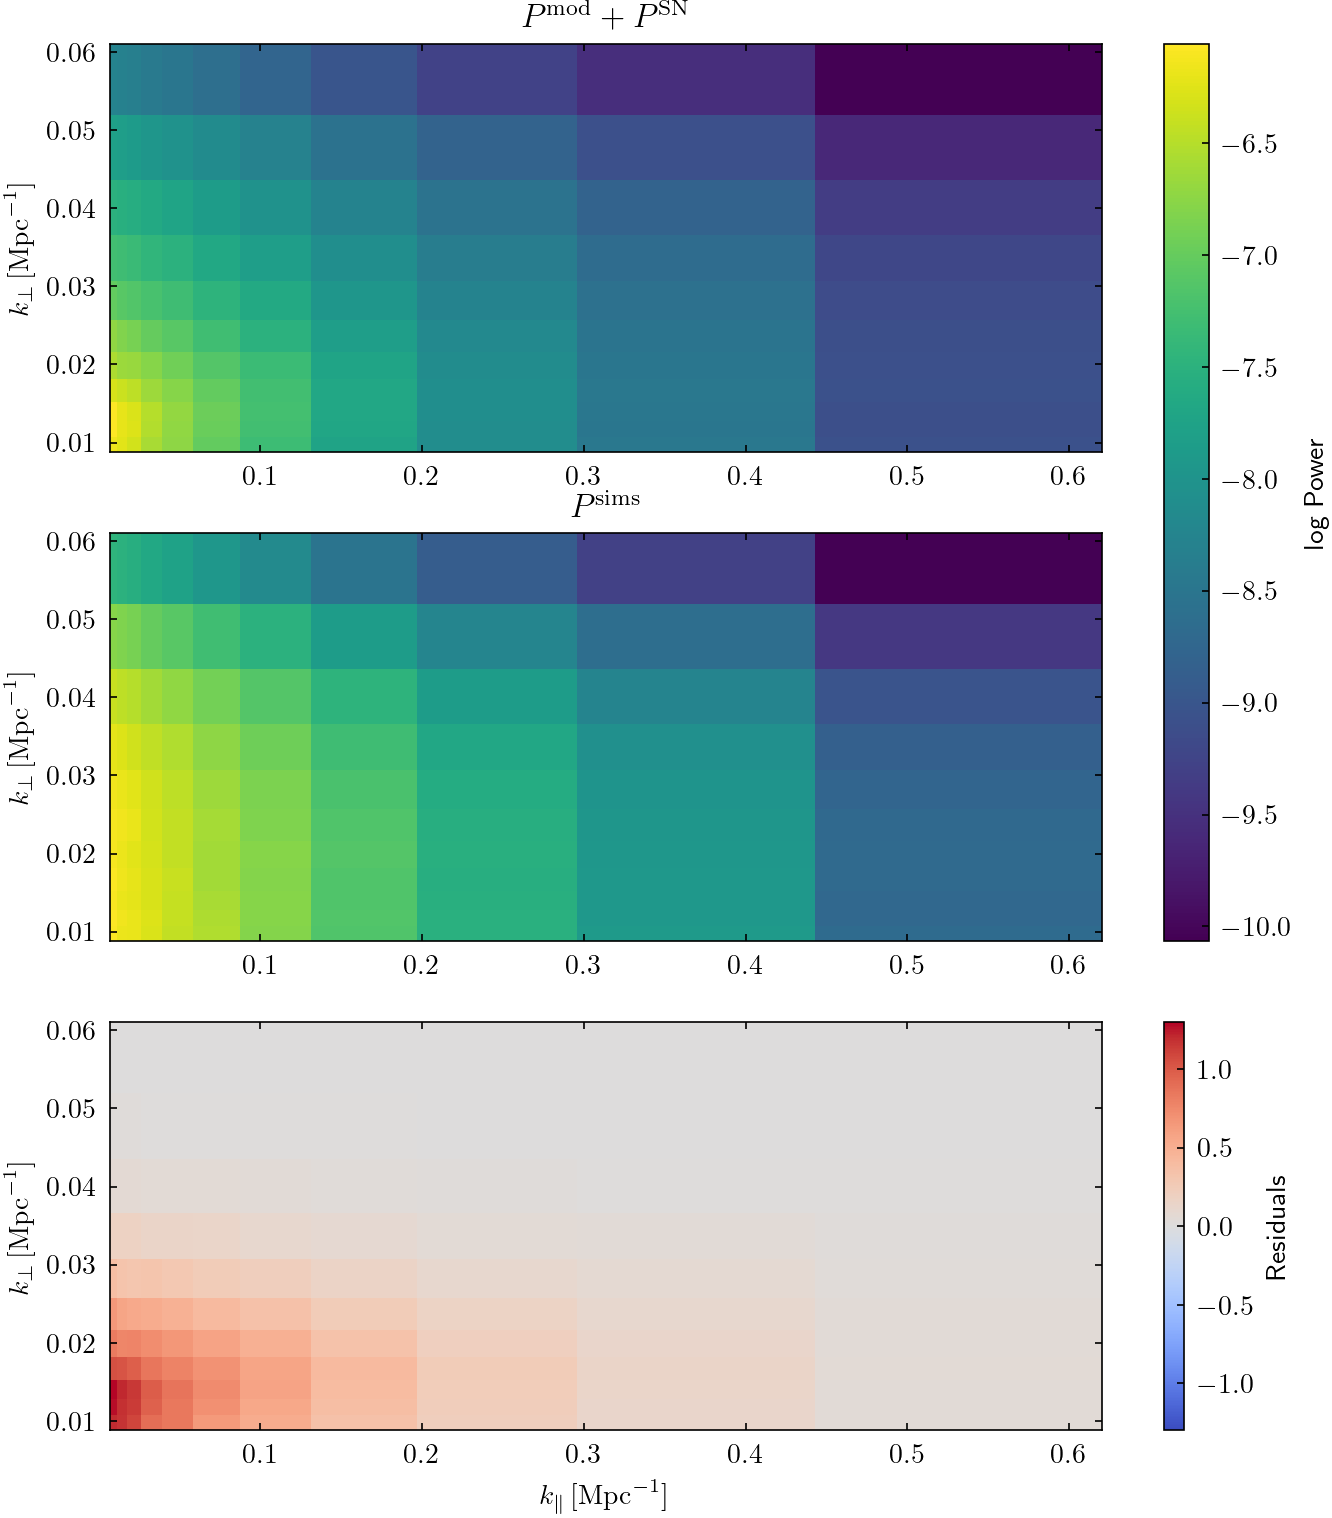

In [ ]:

fw, fh = plt.rcParams['figure.figsize'] 
fig, axs = plt.subplots(3, 1, figsize=(2*fw, 3*fh))

# --- Top two plots (shared colorbar) ---
im0 = axs[0].pcolormesh(kparrc, kperpc, np.log(P_HI_2d + P_noise_sims_2d))
axs[0].set_title(r"$P^{\rm HI}_\mathrm{model} + P^{\rm Noise}$")
im1 = axs[1].pcolormesh(kparrc, kperpc, np.log(P_noise_sims_2d))
axs[1].set_title(r"$P^{\rm sims}$")

# Shared colorbar for axs[0] and axs[1]
cbar1 = fig.colorbar(im0, ax=axs[:2], orientation='vertical')
cbar1.set_label("log Power")

# --- Residuals (third plot) ---
residuals = np.log(P_HI_2d + P_noise_sims_2d) - np.log(P_noise_sims_2d)

# Center colormap at 0
absmax = np.max(np.abs(residuals))
norm = TwoSlopeNorm(vmin=-absmax, vcenter=0, vmax=absmax)

im2 = axs[2].pcolormesh(
    kparrc, kperpc, residuals,
    cmap='coolwarm',
    norm=norm
)

for ax in axs.flatten():
    ax.set_ylabel(r"$k_\perp \,[\mathrm{Mpc}^{-1}]$")
ax.set_xlabel(r"$k_\| \,[\mathrm{Mpc}^{-1}]$")

# Separate colorbar for residuals
cbar2 = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cbar2.set_label("Residuals")

plt.show()


In [77]:
ar = []
with mp.Pool(14) as p:
    for output in p.map(get_1d_power_sims, data_validation_script["phi"]):
        ar.append(output)
P_HI_1d = np.array(ar).mean(0)

ar = []
with mp.Pool(14) as p:
    for output in p.map(get_1d_power_sims, data_full_sims["phi"]):
        ar.append(output)
P_HI_sims_1d = np.array(ar).mean(0)

ar = []
with mp.Pool(14) as p:
    for output in p.map(get_1d_power_sims, data_full_sims["pnoise"]):
        ar.append(output)
P_noise_sims_1d = np.array(ar).mean(0)

Text(0, 0.5, '$k\\,P^{\\rm HI}\\,[\\mathrm{K}^2\\,\\mathrm{Mpc}^{2}]$')

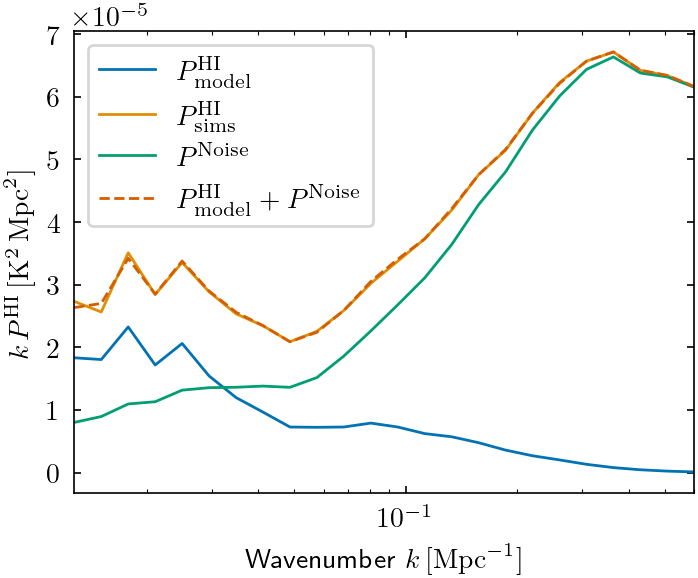

In [80]:
color = iter(Cs)

plt.semilogx(kbc, kbc * P_HI_1d, c=next(color), label=r"$P^{\rm HI}_\mathrm{model}$")
plt.semilogx(kbc, kbc * P_HI_sims_1d, c=next(color), label=r"$P^{\rm HI}_\mathrm{sims}$")
plt.semilogx(kbc, kbc * P_noise_sims_1d, c=next(color), label=r"$P^{\rm Noise}$")
plt.semilogx(kbc, kbc * (P_HI_1d + P_noise_sims_1d), ls="--", c=next(color), label=r"$P^{\rm HI}_\mathrm{model} + P^{\rm Noise}$")
plt.legend()
plt.xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$k\,P^{\rm HI}\,[\mathrm{K}^2\,\mathrm{Mpc}^{2}]$")

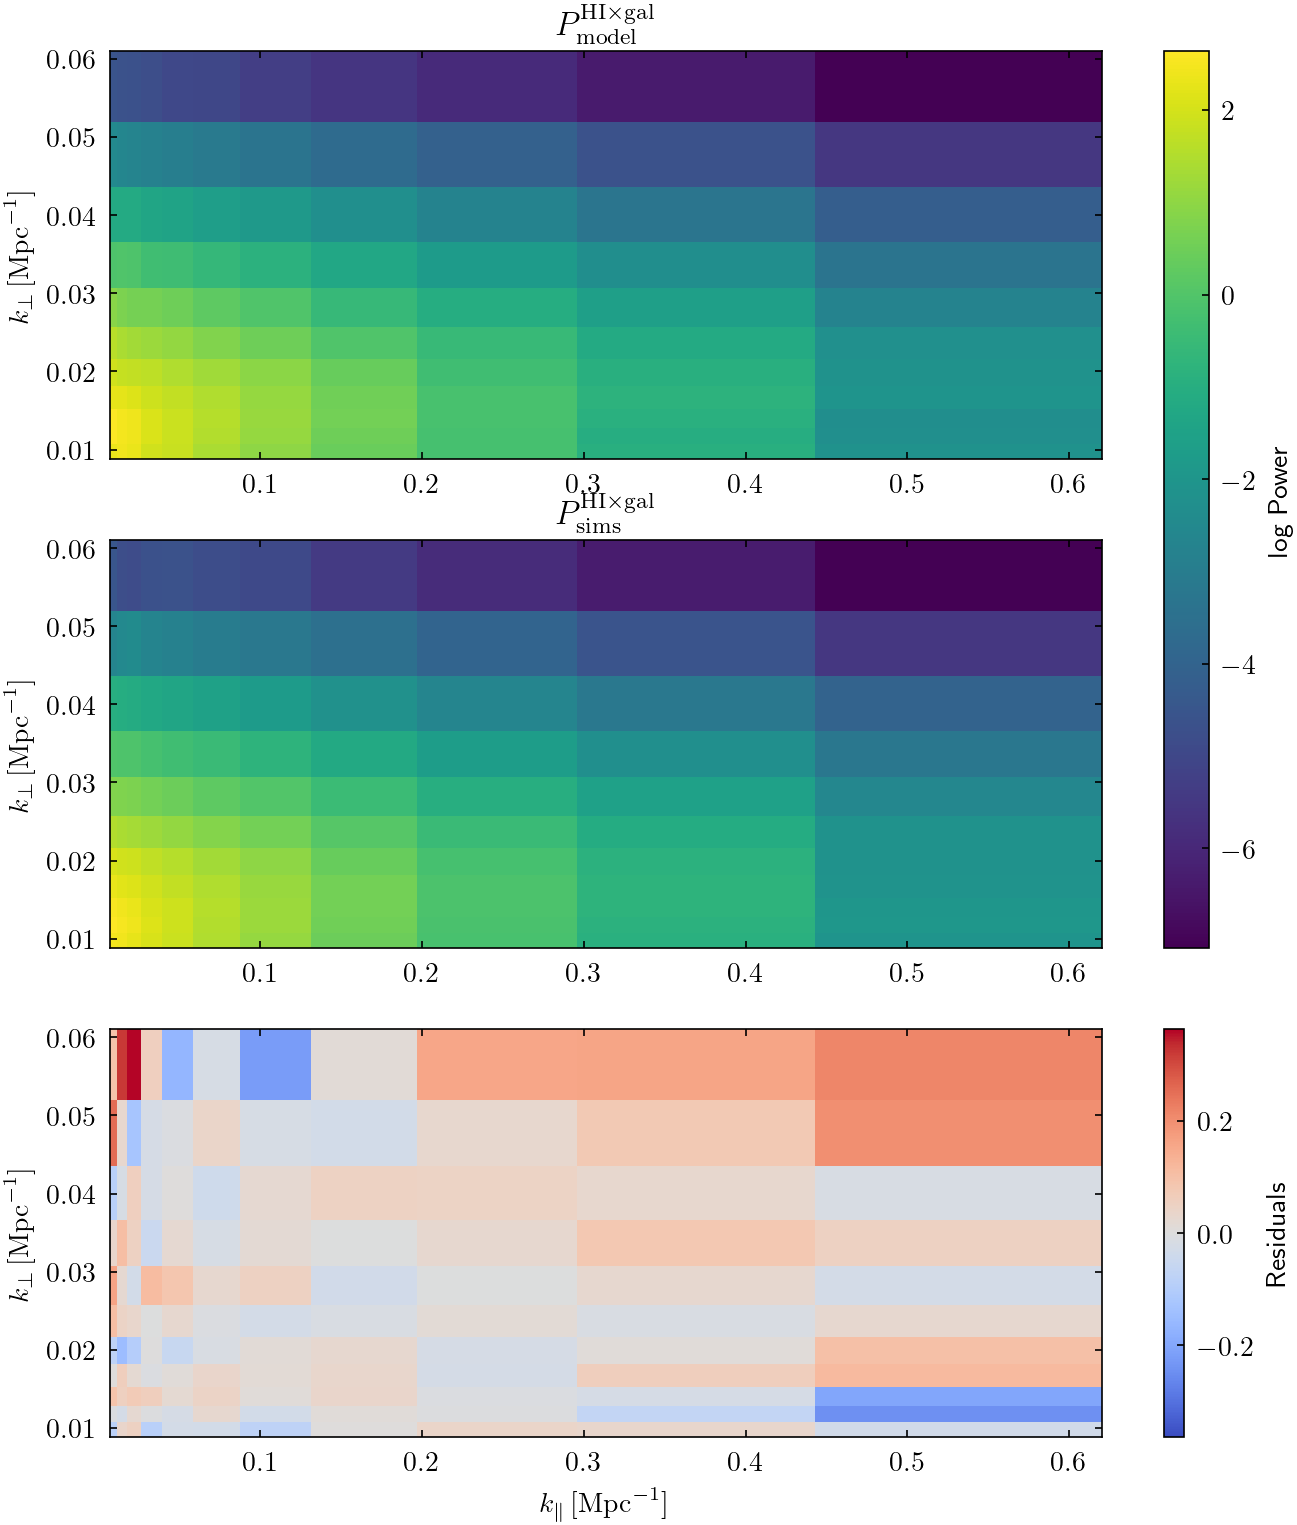

In [85]:
ar = []
with mp.Pool(14) as p:
    for output in p.map(get_cy_power_sims, data_validation_script["phixgal"]):
        ar.append(output)
P_HIxGal_2d = np.array(ar).mean(0)

ar = []
with mp.Pool(14) as p:
    for output in p.map(get_cy_power_sims, data_full_sims["phixgal"]):
        ar.append(output)
P_HIxGal_sims_2d = np.array(ar).mean(0)


fw, fh = plt.rcParams['figure.figsize'] 
fig, axs = plt.subplots(3, 1, figsize=(2*fw, 3*fh))

# --- Top two plots (shared colorbar) ---
im0 = axs[0].pcolormesh(kparrc, kperpc, np.log(P_HIxGal_2d))
axs[0].set_title(r"$P^{\rm HI \times gal}_\mathrm{model}$")
im1 = axs[1].pcolormesh(kparrc, kperpc, np.log(P_HIxGal_sims_2d))
axs[1].set_title(r"$P^{\rm HI \times gal}_\mathrm{sims}$")

# Shared colorbar for axs[0] and axs[1]
cbar1 = fig.colorbar(im0, ax=axs[:2], orientation='vertical')
cbar1.set_label("log Power")

# --- Residuals (third plot) ---
residuals = np.log(P_HIxGal_2d) - np.log(P_HIxGal_sims_2d)

# Center colormap at 0
absmax = np.max(np.abs(residuals))
norm = TwoSlopeNorm(vmin=-absmax, vcenter=0, vmax=absmax)

im2 = axs[2].pcolormesh(
    kparrc, kperpc, residuals,
    cmap='coolwarm',
    norm=norm
)

for ax in axs.flatten():
    ax.set_ylabel(r"$k_\perp \,[\mathrm{Mpc}^{-1}]$")
ax.set_xlabel(r"$k_\| \,[\mathrm{Mpc}^{-1}]$")

# Separate colorbar for residuals
cbar2 = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cbar2.set_label("Residuals")

plt.show()


Text(0, 0.5, '$k\\,P^{\\rm HI \\times gal}\\,[\\mathrm{K}\\,\\mathrm{Mpc}^{2}]$')

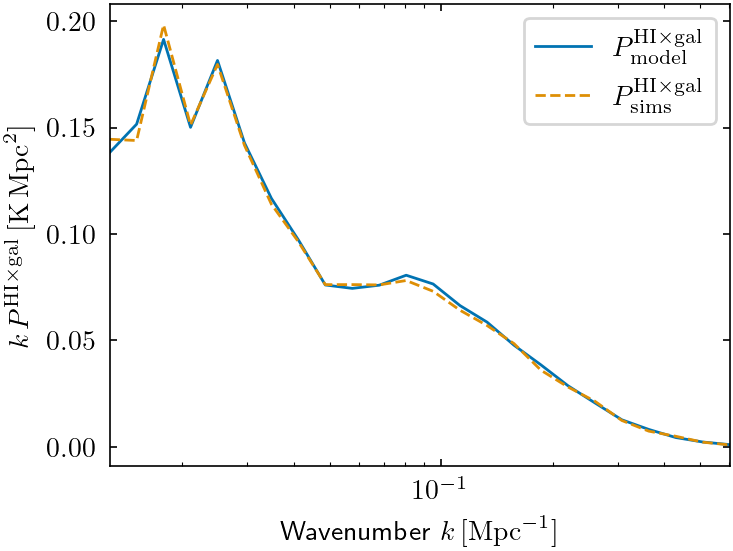

In [83]:
ar = []
with mp.Pool(14) as p:
    for output in p.map(get_1d_power_sims, data_validation_script["phixgal"]):
        ar.append(output)
P_HIxGal_1d = np.array(ar).mean(0)

ar = []
with mp.Pool(14) as p:
    for output in p.map(get_1d_power_sims, data_full_sims["phixgal"]):
        ar.append(output)
P_HIxGal_sims_1d = np.array(ar).mean(0)

color = iter(Cs)
plt.semilogx(kbc, kbc * P_HIxGal_1d, c=next(color), label=r"$P^{\rm HI \times gal}_\mathrm{model}$")
plt.semilogx(kbc, kbc * P_HIxGal_sims_1d, c=next(color), ls="--", label=r"$P^{\rm HI \times gal}_\mathrm{sims}$")
plt.legend()
plt.xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$k\,P^{\rm HI \times gal}\,[\mathrm{K}\,\mathrm{Mpc}^{2}]$")